# Nonlinear complex intertwiner test

Goal: check that the gradient of a cost for a nonlinear, nonreciprocal system can be measured on the same hardware, as the nonlinear part of Theorem 9.1 claims. The notebook recovers the adjoint from two hardware runs (a reverse run and a nudged run) and compares it with a directly computed adjoint, both when the theorem's conditions hold and when each one is broken.

The system is
$$
i\dot u+F(t,u,\bar u)-f(t)=0,\qquad
F(t,u,\bar u)=K(t)u+g\,|u|^2\odot u+\xi\,Y\bar u.
$$
$u$ holds four complex amplitudes and $f$ is the drive. $K(t)$ is a chain whose hopping is stronger in one direction (set by $h$) and carries a phase $\phi$. The term $g|u|^2\odot u$ is a Kerr nonlinearity on each site.
$$
K(t)=
\begin{pmatrix}
\varepsilon_0(t)&b(t)e^{-h+i\phi}&0&0\\
b(t)e^{h-i\phi}&\varepsilon_1(t)&b(t)e^{-h+i\phi}&0\\
0&b(t)e^{h-i\phi}&\varepsilon_2(t)&b(t)e^{-h+i\phi}\\
0&0&b(t)e^{h-i\phi}&\varepsilon_3(t)
\end{pmatrix}
+\eta X+\rho P,
$$
$$
\varepsilon_n(t)=w_n+(-1)^n\alpha\cos(\Omega t),\qquad
b(t)=J+\beta\sin(\Omega t).
$$
All parameters are real. The extra terms $\eta X$, $\rho P$, and $\xi Y\bar u$ are zero in the valid case.

The theorem uses two fixed diagonal matrices:
$$
\mathcal Q=\operatorname{diag}\!\left(e^{-2in\phi}\right),\qquad
S=\operatorname{diag}\!\left(e^{2nh}\right),\qquad n=0,\ldots,3.
$$
- $\mathcal Q$, combined with complex conjugation, lets the hardware run the forward trajectory backward. This requires
$$
F(t,\mathcal Q\bar u,\bar{\mathcal Q}u)=\mathcal Q\,\overline{F(t,u,\bar u)}.\qquad(81)
$$
- $S$ turns the adjoint equation into one the hardware can run. This requires
$$
SF_u^TS^{-1}=\overline{F_u},\qquad S\,\overline{F_{\bar u}}^T\bar S^{-1}=\overline{F_{\bar u}}.\qquad(82),\ (83)
$$

These conditions are independent: (81) concerns the trajectory, while (82) and (83) concern the adjoint. For this model,
$$
F_u=K(t)+2g\,\operatorname{diag}(|u|^2),\qquad F_{\bar u}=g\,\operatorname{diag}(u^2)+\xi Y.
$$

| Term | Effect on the conditions |
|---|---|
| Hopping $b(t)e^{\mp(h-i\phi)}$ | Nonreciprocal and phase-twisted, but satisfies (81) to (83) with this $\mathcal Q$ and $S$. |
| On-site $\varepsilon_n(t)$ and Kerr term | Diagonal, so they satisfy all three. |
| $\eta X$, with $X=i(e^{-2h}U_2-e^{2h}U_2^T)$ | Breaks (81) only. |
| $\rho P$, with $P=e^{i\phi}U+e^{-i\phi}U^T$ | Breaks (82) only. |
| $\xi Y\bar u$, with $Y_{n,n+1}=-Y_{n+1,n}=e^{-i(2n+1)\phi}$ | Breaks (83) only. |

$U$ and $U_2$ shift by one and two sites.

In the linear notebook, one hardware run gives the adjoint. A nonlinear system needs two runs:
1. A reverse run starts from $\mathcal Q\overline{u(T)}$. By (81), it retraces the forward trajectory backward.
2. A nudged run repeats the reverse run with a small cost-dependent nudge of size $\epsilon$.

By (82) and (83), the difference between the runs divided by $\epsilon$ is $\mathcal QSc$. So the adjoint is $c=S^{-1}\mathcal Q^{-1}(w^\epsilon-w)/\epsilon$, exact in the limit $\epsilon\to0$.

The valid case has $h\ne0$, $\phi\ne0$, and $\eta=\rho=\xi=0$. Each broken case turns on one extra term. A broken case only rules out this particular $\mathcal Q$ and $S$; some other pair might still work.

### Setup
Four sites, time from 0 to 5, and a nudge size of $\epsilon=10^{-6}$. `upper` and `upper2` are the shifts $U$ and $U_2$; `alt_profile` is $\operatorname{diag}(1,-1,1,-1)$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp, simpson

N = 4
T = 5.0
Nt = 801
rtol = 1e-10
atol = 1e-12
nudging_epsilon = 1e-6
t_grid = np.linspace(0.0, T, Nt)

initial_condition_names = [f"Re u0[{j}]" for j in range(N)] + [f"Im u0[{j}]" for j in range(N)]
force_parameter_names = [
    "w0", "w1", "w2", "w3", "alpha", "Omega", "J", "beta", "h", "phi", "g", "eta", "rho", "xi",
]
drive_parameter_names = ["A0", "A3", "omega_f", "phase_f"]
parameter_names = initial_condition_names + force_parameter_names + drive_parameter_names

identity = np.eye(N)
site_index = np.arange(N)
upper = np.diag(np.ones(N - 1), 1)
upper2 = np.diag(np.ones(N - 2), 2)
alt_profile = np.diag([1.0, -1.0, 1.0, -1.0])

q_traj = 0.20
q_T = 0.70
u_target = np.array([0.08 + 0.10j, -0.06 - 0.20j, 0.05j, -0.15 + 0.12j])
np.set_printoptions(precision=6, suppress=False)

### Model
`K`, `F`, `F_u`, and `F_ubar` define the model and its Jacobians $F_u$ and $F_{\bar u}$. `Q_matrix` and `S_matrix` build $\mathcal Q$ and $S$ from the current $\phi$ and $h$. `dF_dp` and `drive_dp` are the parameter derivatives used for the gradient. The drive has a phase, so complex drive gradients are tested too.

In [2]:
def make_parameters(eta=0.0, rho=0.0, xi=0.0):
    return np.array(
        [0.55, -0.20, 0.10, 0.05] + [0.12, 0.18, -0.08, 0.15]
        + [0.30, 0.10, -0.05, 0.20, 0.12, 0.90, 0.45, 0.08, 0.30, 0.40, 0.50, eta, rho, xi]
        + [0.08, -0.05, 0.75, 0.40],
        dtype=float,
    )


def unpack(p):
    return dict(zip(parameter_names, p))


def initial_condition(p):
    return np.asarray(p[:N] + 1j * p[N:2*N], dtype=complex)


def Q_matrix(p):
    return np.diag(np.exp(-2j * site_index * unpack(p)["phi"]))


def S_matrix(p):
    return np.diag(np.exp(2.0 * site_index * unpack(p)["h"]))


def biased_hopping(h, phi):
    return np.exp(-h + 1j * phi) * upper + np.exp(h - 1j * phi) * upper.T


def phased_hopping(phi):
    return np.exp(1j * phi) * upper + np.exp(-1j * phi) * upper.T


def flux_hopping(h):
    return 1j * (np.exp(-2.0 * h) * upper2 - np.exp(2.0 * h) * upper2.T)


def conjugate_coupling(phi):
    half_gauge = np.diag(np.exp(-1j * site_index * phi))
    return half_gauge @ (upper - upper.T) @ half_gauge


def K(t, p):
    pars = unpack(p)
    onsite = np.diag([pars["w0"], pars["w1"], pars["w2"], pars["w3"]]).astype(complex)
    onsite = onsite + pars["alpha"] * np.cos(pars["Omega"] * t) * alt_profile
    b = pars["J"] + pars["beta"] * np.sin(pars["Omega"] * t)
    return (
        onsite + b * biased_hopping(pars["h"], pars["phi"])
        + pars["eta"] * flux_hopping(pars["h"]) + pars["rho"] * phased_hopping(pars["phi"])
    )


def F(t, u, p):
    pars = unpack(p)
    return (
        K(t, p) @ u + pars["g"] * np.abs(u)**2 * u
        + pars["xi"] * (conjugate_coupling(pars["phi"]) @ u.conj())
    )


def F_u(t, u, p):
    return K(t, p) + 2.0 * unpack(p)["g"] * np.diag(np.abs(u)**2)


def F_ubar(t, u, p):
    pars = unpack(p)
    return pars["g"] * np.diag(u**2) + pars["xi"] * conjugate_coupling(pars["phi"])


def dF_dp(t, u, p, name):
    pars = unpack(p)
    ct, st = np.cos(pars["Omega"] * t), np.sin(pars["Omega"] * t)
    h, phi = pars["h"], pars["phi"]
    b = pars["J"] + pars["beta"] * st
    H = biased_hopping(h, phi)
    if name in ("w0", "w1", "w2", "w3"):
        out = np.zeros(N, dtype=complex)
        j = int(name[1])
        out[j] = u[j]
        return out
    if name == "alpha":
        return ct * (alt_profile @ u)
    if name == "Omega":
        return -pars["alpha"] * t * st * (alt_profile @ u) + pars["beta"] * t * ct * (H @ u)
    if name == "J":
        return H @ u
    if name == "beta":
        return st * (H @ u)
    if name == "h":
        dH = -np.exp(-h + 1j * phi) * upper + np.exp(h - 1j * phi) * upper.T
        dX = 1j * (-2.0 * np.exp(-2.0 * h) * upper2 - 2.0 * np.exp(2.0 * h) * upper2.T)
        return b * (dH @ u) + pars["eta"] * (dX @ u)
    if name == "phi":
        dH = 1j * np.exp(-h + 1j * phi) * upper - 1j * np.exp(h - 1j * phi) * upper.T
        dH0 = 1j * np.exp(1j * phi) * upper - 1j * np.exp(-1j * phi) * upper.T
        # Entry (n, n+1) and (n+1, n) of Y carry exp(-i(2n+1)phi).
        dY = -1j * (site_index[:, None] + site_index[None, :]) * conjugate_coupling(phi)
        return b * (dH @ u) + pars["rho"] * (dH0 @ u) + pars["xi"] * (dY @ u.conj())
    if name == "g":
        return np.abs(u)**2 * u
    if name == "eta":
        return flux_hopping(h) @ u
    if name == "rho":
        return phased_hopping(phi) @ u
    if name == "xi":
        return conjugate_coupling(phi) @ u.conj()
    raise KeyError(name)


def drive(t, p):
    pars = unpack(p)
    wt, phase = pars["omega_f"] * t, pars["phase_f"]
    return np.array([
        pars["A0"] * np.exp(1j * phase) * np.sin(wt), 0.0, 0.0,
        pars["A3"] * np.exp(-1j * phase) * np.cos(wt),
    ])


def drive_dp(t, p, name):
    pars = unpack(p)
    wt, phase = pars["omega_f"] * t, pars["phase_f"]
    if name == "A0":
        return np.array([np.exp(1j * phase) * np.sin(wt), 0.0, 0.0, 0.0])
    if name == "A3":
        return np.array([0.0, 0.0, 0.0, np.exp(-1j * phase) * np.cos(wt)])
    if name == "omega_f":
        return t * np.array([
            pars["A0"] * np.exp(1j * phase) * np.cos(wt), 0.0, 0.0,
            -pars["A3"] * np.exp(-1j * phase) * np.sin(wt),
        ])
    if name == "phase_f":
        return np.array([1j, 0.0, 0.0, -1j]) * drive(t, p)
    raise KeyError(name)

### Cost and forward run
$$
\chi=\int_0^T\theta(u(t),t)\,dt+\psi(u(T)).
$$
`theta_u` and `psi_u` are the cost derivatives $q(\tau)$ and $q_T$ that set the nudge. They use the convention $\tfrac12 q\,\overline{(u-r)}$, so the gradient formulas below carry a factor $2\,\mathrm{Re}$. The forward run solves $\dot u=i(F-f)$.

In [3]:
def u_reference(t):
    return np.array([
        0.15 * np.exp(0.30j * t), -0.10j * np.exp(-0.20j * t),
        0.08 * np.exp(-0.15j * t), 0.12j * np.exp(0.25j * t),
    ])


def theta_value(u, t):
    residual = u - u_reference(t)
    return 0.5 * q_traj * np.vdot(residual, residual).real


def theta_u(u, t):
    return 0.5 * q_traj * np.conjugate(u - u_reference(t))


def psi_value(u):
    residual = u - u_target
    return 0.5 * q_T * np.vdot(residual, residual).real


def psi_u(u):
    return 0.5 * q_T * np.conjugate(u - u_target)


def integrate(rhs, initial):
    sol = solve_ivp(
        rhs, (0.0, T), np.asarray(initial, dtype=complex),
        t_eval=t_grid, dense_output=True, method="DOP853", rtol=rtol, atol=atol,
    )
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol


def solve_forward(p):
    return integrate(lambda t, u: 1j * (F(t, u, p) - drive(t, p)), initial_condition(p))


def objective(p):
    forward = solve_forward(p)
    values = [theta_value(forward.y[:, k], t) for k, t in enumerate(t_grid)]
    return simpson(values, x=t_grid) + psi_value(forward.y[:, -1])

### Adjoint solvers
`solve_digital_adjoint` solves the adjoint equation directly, as a reference ($r=T-\tau$, Jacobians evaluated at $u(r)$):
$$
i\dot c+F_u(r)^Tc+\overline{F_{\bar u}(r)}^T\bar c+q=0,\qquad c(0)=iq_T.
$$

`physical_nudged_adjoint` performs the two hardware runs. Both use the same $F$, and neither uses $F_u^T$.
- Reverse run: start at $\mathcal Q\overline{u(T)}$ with drive $\mathcal Q\overline{f(r)}$.
- Nudged run: add $\epsilon\,i\mathcal QSq_T$ to the start and subtract $\epsilon\,\mathcal QSq(\tau)$ from the drive.
- Recover $c=S^{-1}\mathcal Q^{-1}(w^\epsilon-w)/\epsilon$.

Setting `Q` or `S` to the identity skips that matrix.

In [4]:
class DenseSolution:
    def __init__(self, t, y, sol):
        self.t = t
        self.y = y
        self.sol = sol


def solve_digital_adjoint(p, forward):
    c0 = 1j * psi_u(forward.y[:, -1])

    def rhs(tau, c):
        r = T - tau
        u = forward.sol(r)
        return 1j * (
            F_u(r, u, p).T @ c
            + F_ubar(r, u, p).conj().T @ c.conj()
            + theta_u(u, r)
        )

    return integrate(rhs, c0)


def physical_nudged_adjoint(p, forward, epsilon=nudging_epsilon, Q=None, S=None, return_runs=False):
    if epsilon == 0:
        raise ValueError("A nonzero nudging amplitude is required for the difference quotient.")
    Q = Q_matrix(p) if Q is None else Q
    S = S_matrix(p) if S is None else S
    QS = Q @ S
    w0 = Q @ forward.y[:, -1].conj()
    d0 = 1j * (QS @ psi_u(forward.y[:, -1]))

    def reverse_rhs(eps):
        def rhs(tau, w):
            r = T - tau
            source = Q @ drive(r, p).conj() - eps * (QS @ theta_u(forward.sol(r), r))
            # Same nonlinear hardware F and parameters; no tangent operators.
            return 1j * (F(r, w, p) - source)
        return rhs

    reverse = integrate(reverse_rhs(0.0), w0)
    nudged = integrate(reverse_rhs(epsilon), w0 + epsilon * d0)
    recover = np.linalg.inv(QS)
    physical = DenseSolution(
        t_grid, recover @ ((nudged.y - reverse.y) / epsilon),
        lambda tau: recover @ ((nudged.sol(tau) - reverse.sol(tau)) / epsilon),
    )
    if return_runs:
        return physical, reverse, nudged
    return physical

### Gradient and diagnostics
For a force parameter $p$,
$$
\frac{\partial\chi}{\partial p}=2\operatorname{Re}\int_0^T c(T-t)^T\frac{\partial F}{\partial p}\,dt.
$$
The product uses a transpose, with no conjugate on $c$. Drive parameters get a minus sign, and initial-state gradients come from $c(T)$.

`condition_defects` measures how far each of (81), (82), and (83) is from holding, along with the same checks for $\mathcal Q=S=I$. `trm_error` checks that the reverse run retraces the forward run.

In [5]:
def gradient_from_adjoint(p, forward, adjoint):
    cT = adjoint.sol(T)
    gradient = list(2.0 * cT.imag) + list(2.0 * cT.real)
    c_forward = adjoint.sol(T - t_grid)

    for name in force_parameter_names:
        # Bilinear c^T F_p equals <conj(c), F_p>_C; do not conjugate c here.
        values = [
            2.0 * np.real(c_forward[:, k] @ dF_dp(t, forward.y[:, k], p, name))
            for k, t in enumerate(t_grid)
        ]
        gradient.append(simpson(values, x=t_grid))

    for name in drive_parameter_names:
        values = [
            -2.0 * np.real(c_forward[:, k] @ drive_dp(t, p, name))
            for k, t in enumerate(t_grid)
        ]
        gradient.append(simpson(values, x=t_grid))

    return np.array(gradient, dtype=float)


def taylor_errors(p, gradients, h_values, direction):
    chi0 = objective(p)
    p_scale = np.mean(np.abs(p))
    errors = {label: [] for label in gradients}
    for h in h_values:
        delta = h * p_scale * direction
        chi_delta = objective(p + delta)
        for label, gradient in gradients.items():
            errors[label].append(abs(chi_delta - chi0 - gradient @ delta))
    return {label: np.array(values) for label, values in errors.items()}


def relative_field_error(reference, estimate):
    numerator = simpson(np.sum(np.abs(estimate - reference)**2, axis=0), x=t_grid)
    denominator = simpson(np.sum(np.abs(reference)**2, axis=0), x=t_grid)
    return np.sqrt(numerator / denominator)


def condition_defects(p, forward):
    Q, S = Q_matrix(p), S_matrix(p)
    S_inv = np.linalg.inv(S)
    defects = []
    for t in t_grid[::20]:
        u = forward.sol(t)
        Fu, Fubar = F_u(t, u, p), F_ubar(t, u, p)
        defects.append([
            np.linalg.norm(F(t, Q @ u.conj(), p) - Q @ F(t, u, p).conj()),
            np.linalg.norm(S @ Fu.T @ S_inv - Fu.conj()),
            np.linalg.norm(S @ Fubar.conj().T @ np.linalg.inv(S.conj()) - Fubar.conj()),
            np.linalg.norm(F(t, u.conj(), p) - F(t, u, p).conj()),
            np.linalg.norm(Fu.T - Fu.conj()),
        ])
    return np.max(defects, axis=0)


def trm_error(p, forward, reverse):
    return relative_field_error(Q_matrix(p) @ forward.sol(T - t_grid).conj(), reverse.y)

### Run the four cases
Only the valid case should match the digital adjoint. With $\rho$ or $\xi$, the reverse run still retraces the forward run, but the adjoint is wrong. With $\eta$, (82) and (83) still hold, but the reverse run goes off track.

In [6]:
def solve_case(label, eta=0.0, rho=0.0, xi=0.0):
    p = make_parameters(eta=eta, rho=rho, xi=xi)
    forward = solve_forward(p)
    digital = solve_digital_adjoint(p, forward)
    physical, reverse, nudged = physical_nudged_adjoint(p, forward, return_runs=True)
    grad_digital = gradient_from_adjoint(p, forward, digital)
    grad_physical = gradient_from_adjoint(p, forward, physical)
    return {
        "label": label, "p": p, "forward": forward, "digital": digital,
        "physical": physical, "reverse": reverse, "nudged": nudged,
        "grad_digital": grad_digital, "grad_physical": grad_physical,
        "defects": condition_defects(p, forward),
        "trm_error": trm_error(p, forward, reverse),
        "field_error": relative_field_error(digital.y, physical.y),
        "gradient_error": np.linalg.norm(grad_physical - grad_digital) / np.linalg.norm(grad_digital),
    }


cases = [
    solve_case("valid"),
    solve_case("TRM broken", eta=0.15),
    solve_case("F_u broken", rho=0.15),
    solve_case("F_ubar broken", xi=0.15),
]

defect_labels = ["(81) Q-TRM", "(82) S F_u", "(83) S F_ubar", "plain TRM", "plain F_u"]
for result in cases:
    print(result["label"])
    print("  defects:", dict(zip(defect_labels, np.round(result["defects"], 6))))
    print(f"  TRM relative trajectory error: {result['trm_error']:.3e}")
    print(f"  relative physical/digital field error: {result['field_error']:.3e}")
    print(f"  relative physical/digital gradient error: {result['gradient_error']:.3e}")
    print()

valid
  defects: {'(81) Q-TRM': np.float64(0.0), '(82) S F_u': np.float64(0.0), '(83) S F_ubar': np.float64(0.0), 'plain TRM': np.float64(0.654121), 'plain F_u': np.float64(0.790673)}
  TRM relative trajectory error: 1.241e-10
  relative physical/digital field error: 3.072e-06
  relative physical/digital gradient error: 3.467e-06

TRM broken
  defects: {'(81) Q-TRM': np.float64(0.271201), '(82) S F_u': np.float64(0.0), '(83) S F_ubar': np.float64(0.0), 'plain TRM': np.float64(0.740746), 'plain F_u': np.float64(0.878113)}
  TRM relative trajectory error: 4.752e-01
  relative physical/digital field error: 5.411e-01
  relative physical/digital gradient error: 9.128e-01

F_u broken
  defects: {'(81) Q-TRM': np.float64(0.0), '(82) S F_u': np.float64(0.243645), '(83) S F_ubar': np.float64(0.0), 'plain TRM': np.float64(0.783462), 'plain F_u': np.float64(0.790673)}
  TRM relative trajectory error: 1.350e-10
  relative physical/digital field error: 2.968e-01
  relative physical/digital gradient

### Taylor test
For a correct gradient, the error $|\chi(p+\delta)-\chi(p)-g^T\delta|$ shrinks like $h^2$ as the step shrinks. For a wrong gradient, it shrinks like $h$. Expect $h^2$ for the valid case and $h$ for everything else. Here $h$ is the step size, not the hopping bias.

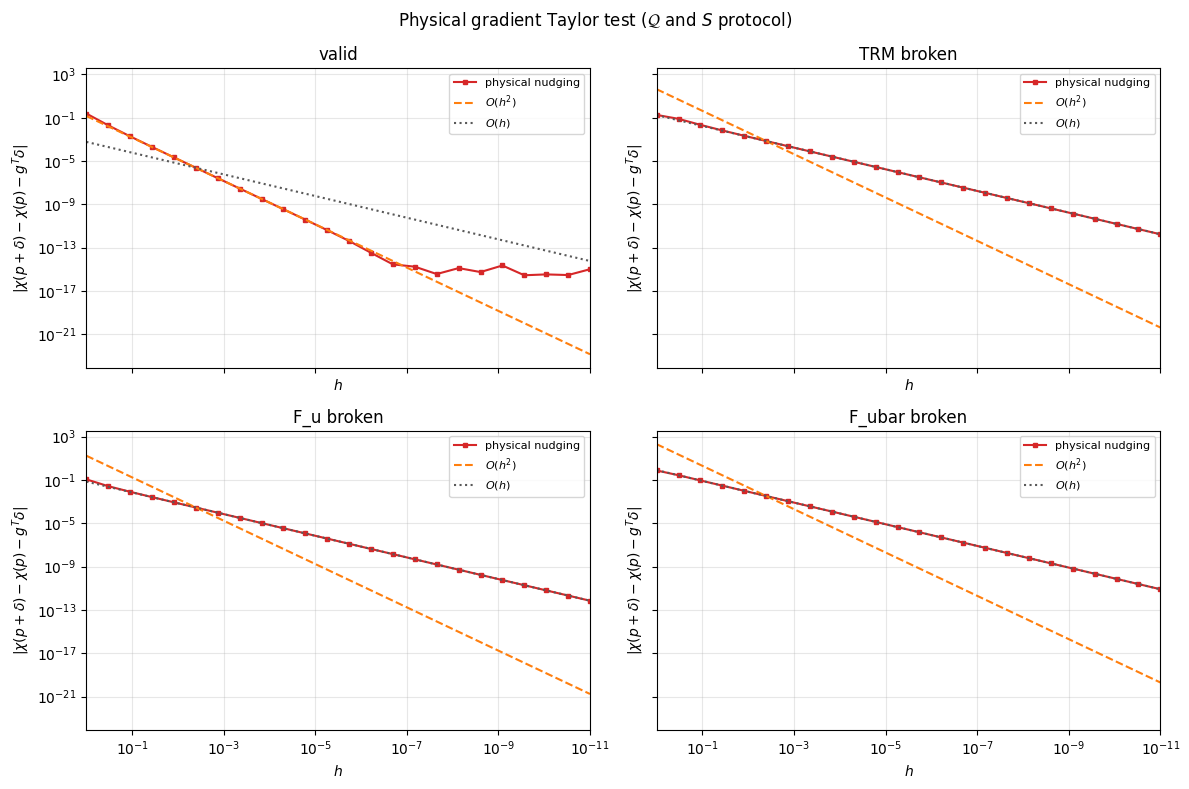

In [7]:
rng = np.random.default_rng(11)
direction = rng.normal(size=len(parameter_names))
direction /= np.linalg.norm(direction)
h_values = np.logspace(0, -11, 24)

for result in cases:
    gradients = {"physical nudging": result["grad_physical"], "digital adjoint": result["grad_digital"]}
    result["taylor"] = taylor_errors(result["p"], gradients, h_values, direction)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, result in zip(axes.flat, cases):
    errors = result["taylor"]["physical nudging"]
    anchor = 5
    ax.loglog(h_values, errors, "s-", ms=3, color="tab:red", label="physical nudging")
    ax.loglog(h_values, errors[anchor] * (h_values / h_values[anchor])**2,
              "--", color="tab:orange", label=r"$O(h^2)$")
    ax.loglog(h_values, errors[anchor] * (h_values / h_values[anchor]),
              ":", color="0.35", label=r"$O(h)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.set_title(result["label"])
    ax.set_xlabel(r"$h$")
    ax.set_ylabel(r"$|\chi(p+\delta)-\chi(p)-g^T\delta|$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle(r"Physical gradient Taylor test ($\mathcal{Q}$ and $S$ protocol)")
plt.tight_layout()
plt.show()


### Nudge size
The result is exact only as $\epsilon\to0$. In the valid case, cutting $\epsilon$ by 10 should cut the error by 10, until numerical error takes over. In the broken cases, the error stays large for every $\epsilon$.

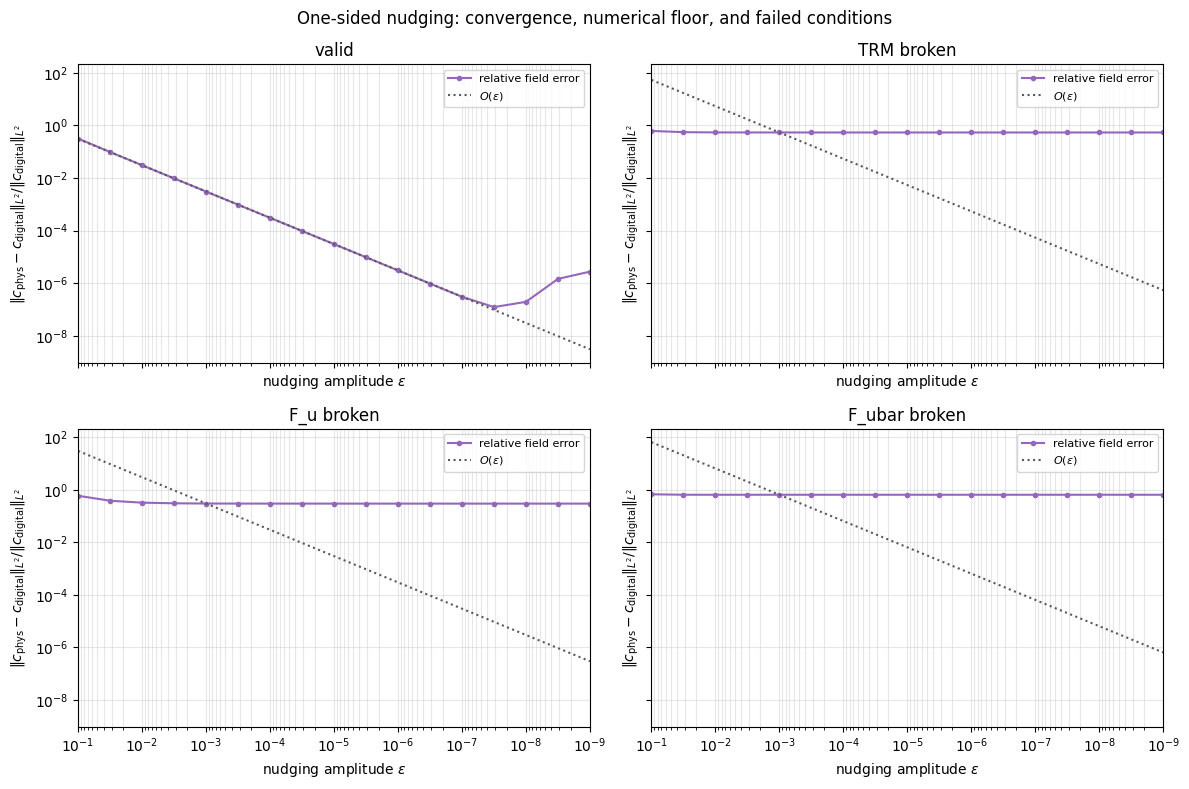

In [8]:
epsilon_values = np.logspace(-1, -9, 17)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, result in zip(axes.flat, cases):
    errors = []
    for epsilon in epsilon_values:
        physical = physical_nudged_adjoint(result["p"], result["forward"], epsilon=epsilon)
        errors.append(relative_field_error(result["digital"].y, physical.y))
    result["epsilon_errors"] = np.array(errors)
    anchor = 4
    ax.loglog(epsilon_values, errors, "o-", ms=3, color="tab:purple", label="relative field error")
    ax.loglog(epsilon_values, errors[anchor] * epsilon_values / epsilon_values[anchor],
              ":", color="0.35", label=r"$O(\epsilon)$")
    ax.set_xlim(epsilon_values[0], epsilon_values[-1])
    ax.set_title(result["label"])
    ax.set_xlabel(r"nudging amplitude $\epsilon$")
    ax.set_ylabel(r"$\|c_{\rm phys}-c_{\rm digital}\|_{L^2}/\|c_{\rm digital}\|_{L^2}$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("One-sided nudging: convergence, numerical floor, and failed conditions")
plt.tight_layout()
plt.show()

### Digital adjoint check
The digital adjoint should give $h^2$ in all four cases, which confirms the gradient code itself.

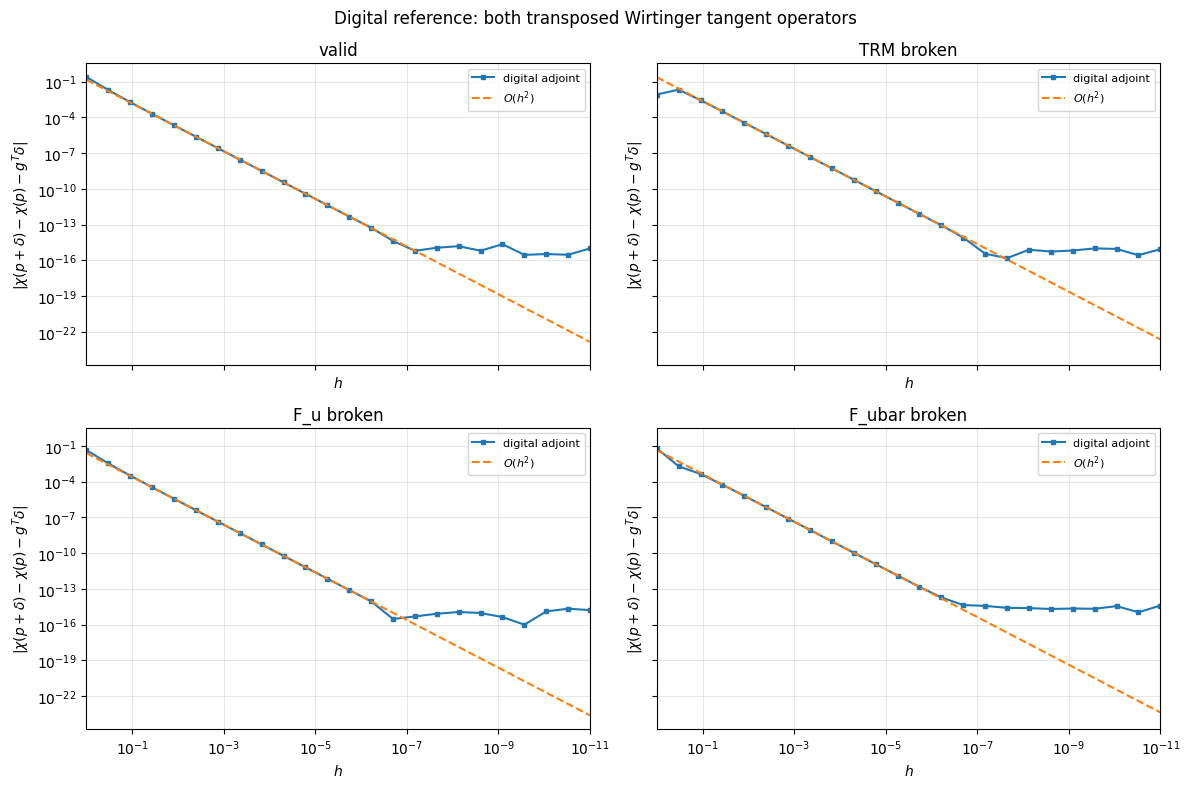

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
for ax, result in zip(axes.flat, cases):
    errors = result["taylor"]["digital adjoint"]
    anchor = 5
    ax.loglog(h_values, errors, "s-", ms=3, color="tab:blue", label="digital adjoint")
    ax.loglog(h_values, errors[anchor] * (h_values / h_values[anchor])**2,
              "--", color="tab:orange", label=r"$O(h^2)$")
    ax.set_xlim(h_values[0], h_values[-1])
    ax.set_title(result["label"])
    ax.set_xlabel(r"$h$")
    ax.set_ylabel(r"$|\chi(p+\delta)-\chi(p)-g^T\delta|$")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(fontsize=8)
fig.suptitle("Digital reference: both transposed Wirtinger tangent operators")
plt.tight_layout()
plt.show()

### Automated checks
The assertions below check that:
- each defect matches its exact formula in `analytic_defects`, both along the trajectory and at random states off it (condition (81) must hold for any state);
- with $\eta=\rho=\xi=0$, the linear part satisfies $(\mathcal QS)K^T(\mathcal QS)^{-1}=K$, the linear notebook's condition with $\mathcal QS$ as the intertwiner;
- each extra term breaks only its own condition;
- the digital gradient matches finite differences;
- the physical gradient passes only in the valid case.

In [ ]:
def finite_difference_gradient(p, step=1e-5):
    gradient = np.empty_like(p)
    for j in range(p.size):
        delta = np.zeros_like(p)
        delta[j] = step * max(1.0, abs(p[j]))
        gradient[j] = (objective(p + delta) - objective(p - delta)) / (2.0 * delta[j])
    return gradient


def fitted_order(x, errors, lower, upper):
    mask = (x >= lower) & (x <= upper)
    return np.polyfit(np.log(x[mask]), np.log(errors[mask]), 1)[0]


def analytic_defects(p):
    pars = unpack(p)
    h, phi = pars["h"], pars["phi"]
    gauge = np.diag(np.exp(1j * site_index * phi))
    trm = 2j * np.cos(2.0 * phi) * (np.exp(-2.0 * h + 2j * phi) * upper2 - np.exp(2.0 * h - 2j * phi) * upper2.T)
    tangent_u = -2.0 * np.sinh(h) * (np.exp(-h - 1j * phi) * upper - np.exp(h + 1j * phi) * upper.T)
    tangent_ubar = -2.0 * np.cosh(h) * gauge @ (np.exp(-h) * upper - np.exp(h) * upper.T) @ gauge
    return pars["eta"] * trm, pars["rho"] * tangent_u, pars["xi"] * tangent_ubar


rng_domain = np.random.default_rng(3)
for result in cases:
    p = result["p"]
    Q, S = Q_matrix(p), S_matrix(p)
    trm_defect, tangent_u_defect, tangent_ubar_defect = analytic_defects(p)
    # Forward states along the schedule, then random states off the trajectory.
    samples = [(t, result["forward"].sol(t)) for t in t_grid[::20]]
    samples += [
        (t, 0.5 * (rng_domain.normal(size=N) + 1j * rng_domain.normal(size=N)))
        for t in rng_domain.uniform(0.0, T, 20)
    ]
    for t, u in samples:
        Fu, Fubar = F_u(t, u, p), F_ubar(t, u, p)
        np.testing.assert_allclose(
            F(t, Q @ u.conj(), p) - Q @ F(t, u, p).conj(), trm_defect @ Q @ u.conj(), atol=1e-13,
        )
        np.testing.assert_allclose(S @ Fu.T @ np.linalg.inv(S) - Fu.conj(), tangent_u_defect, atol=1e-12)
        np.testing.assert_allclose(
            S @ Fubar.conj().T @ np.linalg.inv(S.conj()) - Fubar.conj(), tangent_ubar_defect, atol=1e-12,
        )

valid = next(result for result in cases if result["label"] == "valid")
QS_valid = Q_matrix(valid["p"]) @ S_matrix(valid["p"])
for t in t_grid[::20]:
    K_t = K(t, valid["p"])
    np.testing.assert_allclose(QS_valid @ K_t.T @ np.linalg.inv(QS_valid), K_t, atol=1e-12)

expected_defects = [
    (False, False, False), (True, False, False),
    (False, True, False), (False, False, True),
]
for result, expected in zip(cases, expected_defects):
    np.testing.assert_array_equal(result["defects"][:3] > 1e-10, expected)
    assert np.all(result["defects"][3:] > 1e-2), (result["label"], result["defects"])
    fd = finite_difference_gradient(result["p"])
    result["grad_finite_difference"] = fd
    np.testing.assert_allclose(result["grad_digital"], fd, rtol=2e-5, atol=2e-7)
    digital_order = fitted_order(h_values, result["taylor"]["digital adjoint"], 1e-4, 1e-2)
    assert 1.8 < digital_order < 2.2, (result["label"], digital_order)
    print(f"{result['label']}: digital Taylor order={digital_order:.3f}, "
          f"max component FD error={np.max(np.abs(result['grad_digital'] - fd)):.3e}")

np.testing.assert_allclose(valid["grad_physical"], valid["grad_finite_difference"], rtol=2e-4, atol=2e-6)
assert valid["trm_error"] < 1e-7
assert valid["field_error"] < 1e-5
assert valid["gradient_error"] < 1e-5
physical_order = fitted_order(h_values, valid["taylor"]["physical nudging"], 1e-4, 1e-2)
epsilon_order = fitted_order(epsilon_values, valid["epsilon_errors"], 1e-4, 1e-2)
assert 1.8 < physical_order < 2.2, physical_order
assert 0.8 < epsilon_order < 1.2, epsilon_order
assert cases[1]["trm_error"] > 1e-2
for result in cases[2:]:
    assert result["trm_error"] < 1e-7
for result in cases[1:]:
    assert result["field_error"] > 1e-2
    assert result["gradient_error"] > 1e-2
    assert np.min(result["epsilon_errors"][-7:]) > 1e-2
    order = fitted_order(h_values, result["taylor"]["physical nudging"], 1e-4, 1e-2)
    assert 0.8 < order < 1.2, (result["label"], order)

print(f"valid physical Taylor order={physical_order:.3f}; nudging order={epsilon_order:.3f}")
print("All analytic-defect, condition-isolation, finite-difference, Taylor, and nudging checks passed.")